In [51]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import RandomOverSampler

DATA COLLECTING 

In [52]:
BASE = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT"
GDB  = fr"{BASE}\2022_RBI25K_KAB_BANYUMAS_KUGI50_20221231.gdb"
GADM = fr"{BASE}\indonesiaSHPLevel3\gadm41_IDN_3.shp"
OUT  = Path(fr"{BASE}\outputs"); OUT.mkdir(parents=True, exist_ok=True)

def p99(x): 
    return np.nanpercentile(x, 99)

1) DATA COLLECTING & CLEANING  → shapefile layer dasar

In [56]:
bms_adm = gpd.read_file(GADM)
bms_adm = bms_adm[bms_adm["NAME_2"] == "Banyumas"].to_crs(32749)
bms_boundary = bms_adm.dissolve(by="NAME_2")

# Layer tematik dari GDB
layer_hijau = ["HUTANLAHANTINGGI_AR_25K","HUTANLAHANRENDAH_AR_25K","HERBADANRUMPUT_AR_25K","HUTANTANAMAN_AR_25K"]
layer_bgn   = ["PERUMAHAN_AR_25K","PERMUKIMAN_AR_25K"]
layer_jln   = "JALAN_LN_25K"

hijau_list = [gpd.read_file(GDB, layer=l) for l in layer_hijau]
area_hijau = gpd.GeoDataFrame(pd.concat(hijau_list, ignore_index=True), crs=hijau_list[0].crs).to_crs(32749)

bgn_list   = [gpd.read_file(GDB, layer=l) for l in layer_bgn]
bangunan   = gpd.GeoDataFrame(pd.concat(bgn_list, ignore_index=True), crs=bgn_list[0].crs).to_crs(32749)

jalan      = gpd.read_file(GDB, layer=layer_jln).to_crs(32749)


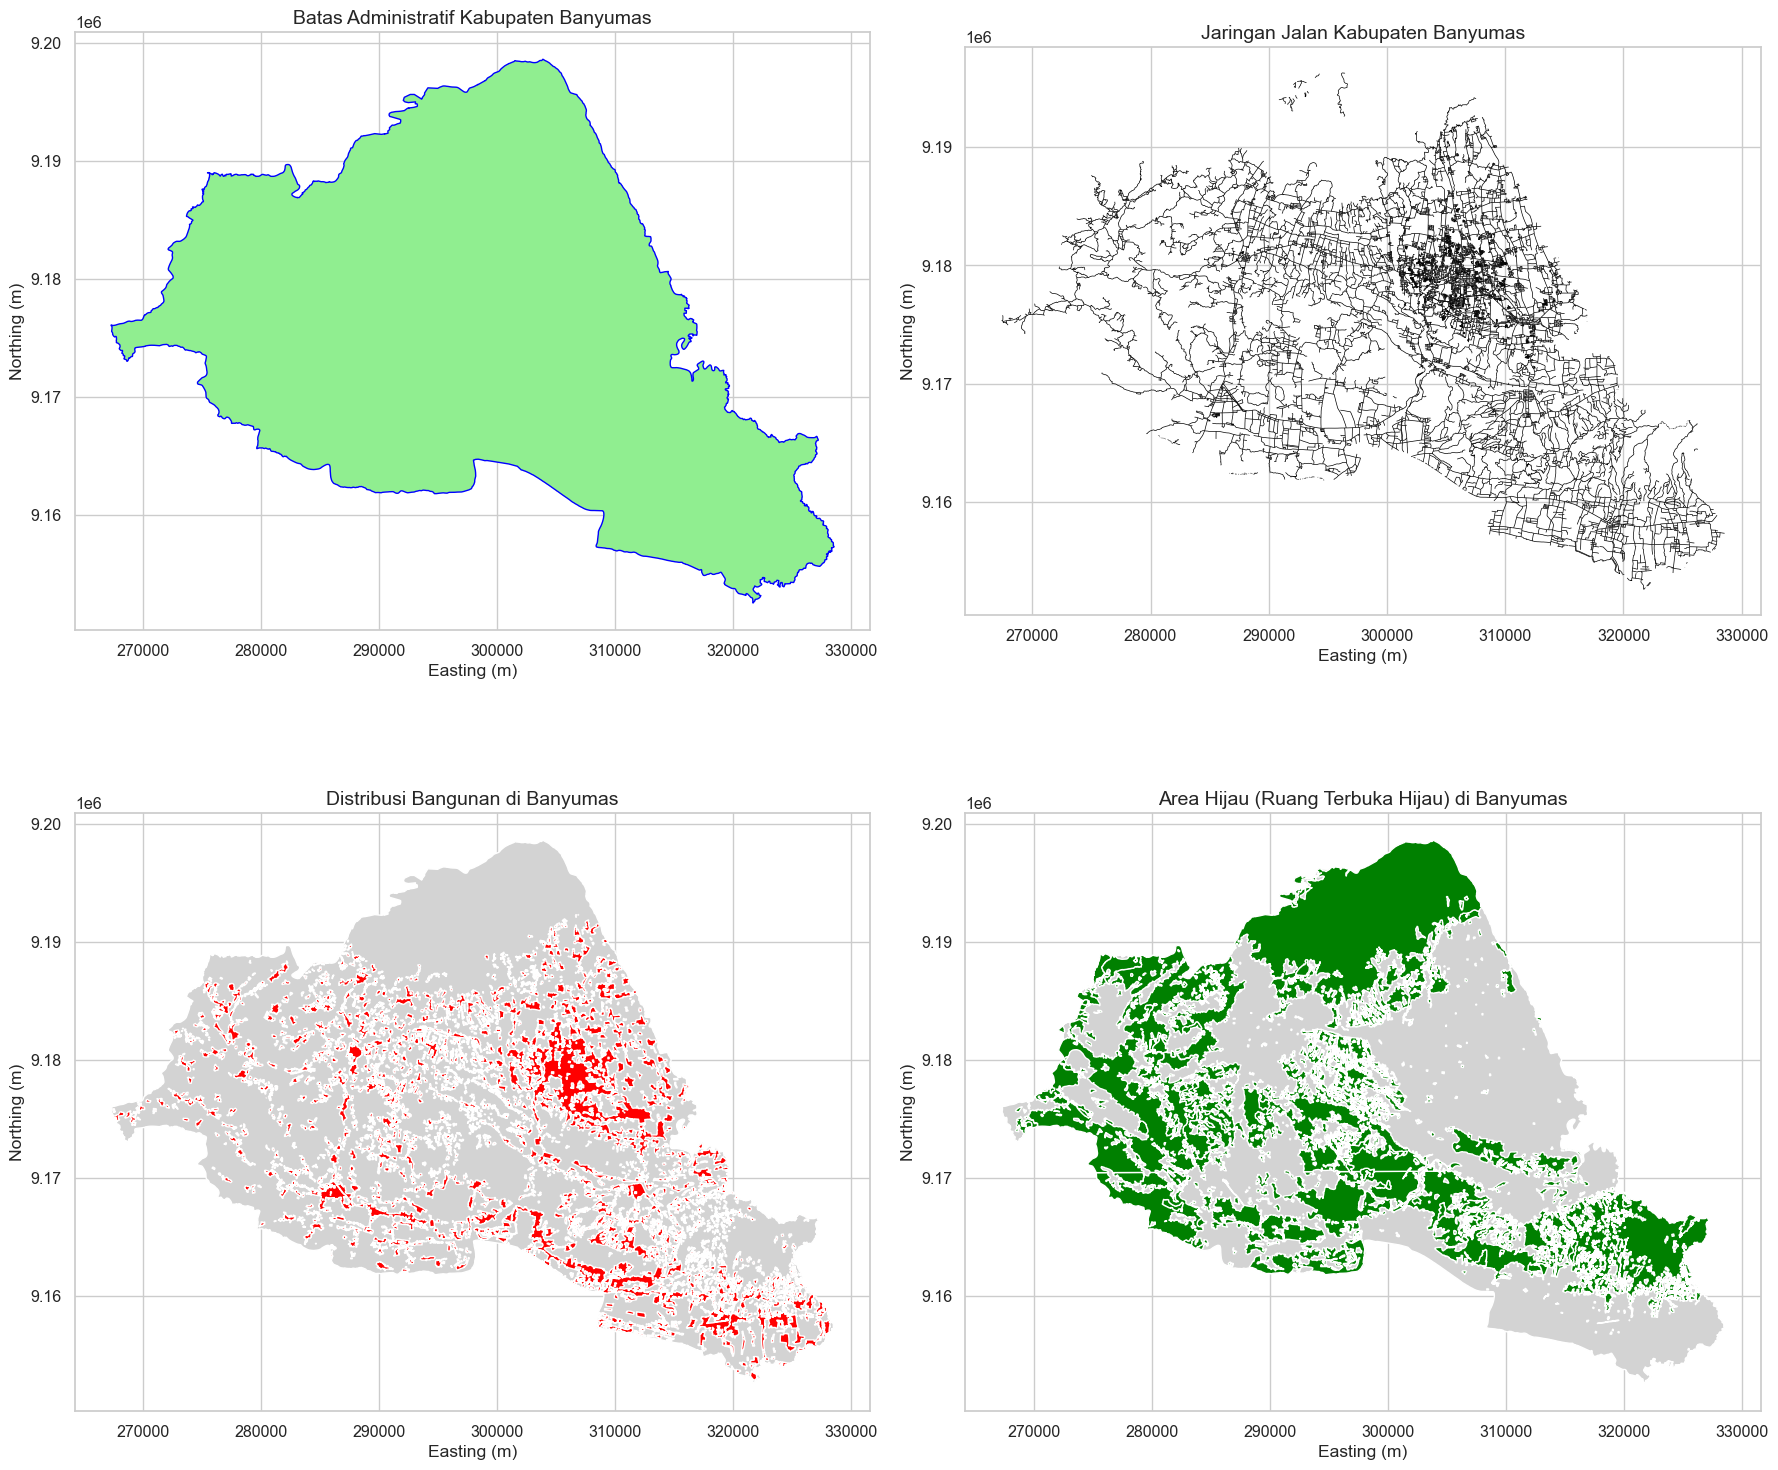

In [58]:
# Clip ke batas Banyumas
area_hijau_bms = gpd.clip(area_hijau, bms_boundary)
bangunan_bms   = gpd.clip(bangunan,   bms_boundary)
jalan_bms      = gpd.clip(jalan,      bms_boundary)

# Visualisasi
fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# Batas Administratif
bms_boundary.plot(ax=axs[0, 0], color="lightgreen", edgecolor="blue")
axs[0, 0].set_title("Batas Administratif Kabupaten Banyumas", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)")
axs[0, 0].set_ylabel("Northing (m)")

# Jaringan Jalan
jalan_bms.plot(ax=axs[0, 1], color="black", linewidth=0.5)
axs[0, 1].set_title("Jaringan Jalan Kabupaten Banyumas", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)")
axs[0, 1].set_ylabel("Northing (m)")

# Distribusi Bangunan
bms_boundary.plot(ax=axs[1, 0], color="lightgrey", edgecolor="white")
bangunan_bms.plot(ax=axs[1, 0], color="red", markersize=0.1)
axs[1, 0].set_title("Distribusi Bangunan di Banyumas", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)")
axs[1, 0].set_ylabel("Northing (m)")

# Area Hijau
bms_boundary.plot(ax=axs[1, 1], color="lightgrey", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 1], color="green")
axs[1, 1].set_title("Area Hijau (Ruang Terbuka Hijau) di Banyumas", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)")
axs[1, 1].set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()


2) GRID GENERATION → data grid

In [59]:
minx, miny, maxx, maxy = bms_boundary.total_bounds
GRID_SIZE = 500  # m

cols = np.arange(minx, maxx, GRID_SIZE)
rows = np.arange(miny, maxy, GRID_SIZE)

grid_cells = [box(x, y, x + GRID_SIZE, y + GRID_SIZE) for x in cols for y in rows]
grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs=bms_boundary.crs)
grid = gpd.overlay(grid, bms_boundary, how="intersection").reset_index(drop=True)
grid["grid_id"] = np.arange(1, len(grid) + 1)
grid["cell_area_m2"] = grid.geometry.area

# Tambah atribut kecamatan (NAME_3 → kecamatan)
assert "NAME_3" in bms_adm.columns, f"Kolom NAME_3 tidak ada. Kolom tersedia: {bms_adm.columns.tolist()}"
grid = gpd.sjoin(grid, bms_adm[["NAME_3","geometry"]], how="left", predicate="intersects")\
         .rename(columns={"NAME_3":"kecamatan"}).drop(columns=["index_right"])


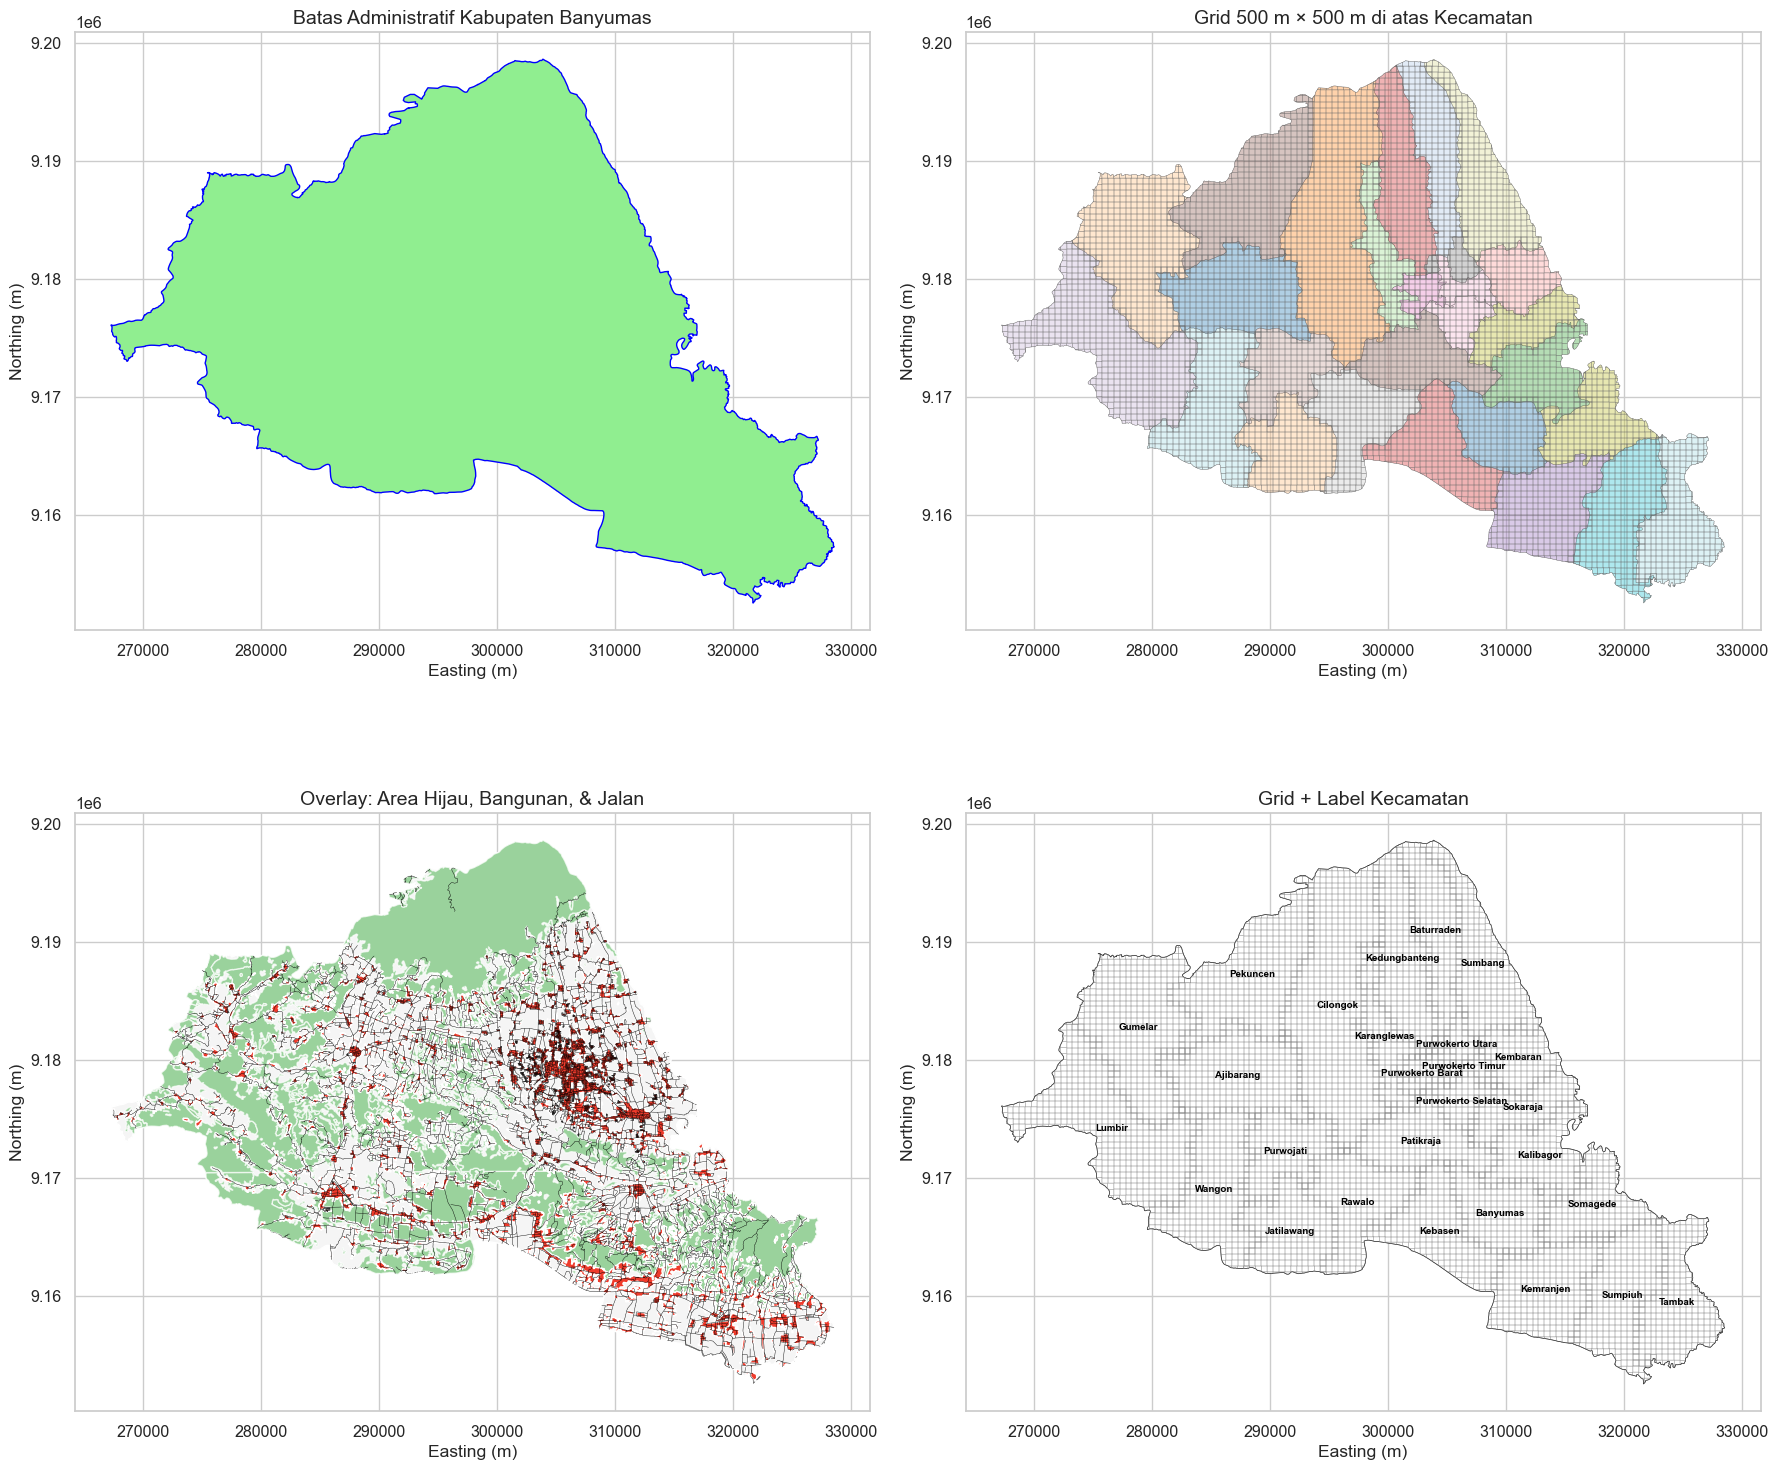

✅ grid_with_kec siap. Kolom tersedia: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NL_NAME_2', 'NAME_3_left', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry', 'grid_id', 'cell_area_m2', 'NAME_3_right', 'kecamatan']


In [62]:
# ==== SAFETY GUARD: siapkan banyumas_kab & bms_boundary kalau belum ada ====
try:
    _ = banyumas_kab  # cek sudah ada?
except NameError:
    # >>> GANTI path ini jika perlu <<<
    banyumas_shp = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\indonesiaSHPLevel3\gadm41_IDN_3.shp"

    banyumas_kab = gpd.read_file(banyumas_shp)
    # filter ke Kab. Banyumas dan set CRS proyek (UTM 49S)
    assert "NAME_2" in banyumas_kab.columns, "Kolom 'NAME_2' tidak ada di shapefile Level-3."
    banyumas_kab = banyumas_kab[banyumas_kab["NAME_2"] == "Banyumas"].to_crs(epsg=32749)

try:
    _ = bms_boundary
except NameError:
    # dissolve jadi boundary kabupaten
    bms_boundary = banyumas_kab.dissolve(by="NAME_2")

# ==== VALIDASI GRID ====
try:
    _ = grid
except NameError:
    raise NameError("Variabel 'grid' belum dibuat. Jalankan dulu cell 'Convert to Grid' yang membuat grid GeoDataFrame.")

# ==== CLIP LAYER-LAYER KE BANYUMAS (pakai nama konsisten *_bms) ====
# Pastikan area_hijau, bangunan, jalan sudah ada; kalau belum, beri pesan jelas
for _var in ["area_hijau", "bangunan", "jalan"]:
    if _var not in locals():
        raise NameError(f"Variabel '{_var}' belum ada. Pastikan sudah load dari GDB sebelumnya.")

area_hijau_bms = gpd.clip(area_hijau, bms_boundary)
bangunan_bms   = gpd.clip(bangunan,   bms_boundary)
jalan_bms      = gpd.clip(jalan,      bms_boundary)

# ==== PLOT 2x2 ====
fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# (A) Batas Administratif
bms_boundary.plot(ax=axs[0, 0], color="lightgreen", edgecolor="blue")
axs[0, 0].set_title("Batas Administratif Kabupaten Banyumas", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)"); axs[0, 0].set_ylabel("Northing (m)")

# (B) Grid di atas warna kecamatan
banyumas_kab.plot(
    ax=axs[0, 1],
    column="NAME_3", cmap="tab20", alpha=0.35,
    edgecolor="black", linewidth=0.3
)
grid.boundary.plot(ax=axs[0, 1], color="dimgray", linewidth=0.2)
axs[0, 1].set_title("Grid 500 m × 500 m di atas Kecamatan", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)"); axs[0, 1].set_ylabel("Northing (m)")
axs[0, 1].set_aspect("equal")

# (C) Overlay Jalan + Bangunan + Area Hijau
bms_boundary.plot(ax=axs[1, 0], color="#f5f5f5", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 0], color="#74c476", alpha=0.7)     # hijau
bangunan_bms.plot(ax=axs[1, 0], color="#ef3b2c", markersize=0.2)  # merah
jalan_bms.plot(ax=axs[1, 0], color="black", linewidth=0.3)        # hitam
axs[1, 0].set_title("Overlay: Area Hijau, Bangunan, & Jalan", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)"); axs[1, 0].set_ylabel("Northing (m)")
axs[1, 0].set_aspect("equal")

# (D) Grid + label kecamatan
bms_boundary.plot(ax=axs[1, 1], color="white", edgecolor="black", linewidth=0.5)
grid.boundary.plot(ax=axs[1, 1], color="gray", linewidth=0.2)
for _, row in banyumas_kab.iterrows():
    c = row.geometry.centroid
    axs[1, 1].text(c.x, c.y, str(row["NAME_3"]), fontsize=7, ha="center", va="center", weight="bold", color="black")
axs[1, 1].set_title("Grid + Label Kecamatan", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)"); axs[1, 1].set_ylabel("Northing (m)")
axs[1, 1].set_aspect("equal")

plt.tight_layout(); plt.show()

# ==== SPATIAL JOIN: atribut kecamatan -> grid ====
KecamatanCol = "NAME_3"
assert KecamatanCol in banyumas_kab.columns, f"Kolom '{KecamatanCol}' tidak ditemukan. Kolom tersedia: {banyumas_kab.columns.tolist()}"

grid = grid.copy()
grid["grid_id"] = np.arange(1, len(grid) + 1)

grid_with_kec = gpd.sjoin(
    grid,
    banyumas_kab[[KecamatanCol, "geometry"]],
    how="left",
    predicate="intersects"
).rename(columns={KecamatanCol: "kecamatan"}).drop(columns=["index_right"])

print("✅ grid_with_kec siap. Kolom tersedia:", grid_with_kec.columns.tolist())


3) FEATURE ENGINEERING → variabel numerik per grid
    (luas hijau, luas bangunan, panjang jalan + turunan)

In [63]:
import geopandas as gpd
import pandas as pd
import numpy as np

def _require_gdf(x, name):
    if x is None:
        raise ValueError(f"Layer '{name}' belum diisi (None). Berikan GeoDataFrame yang valid.")
    if not isinstance(x, gpd.GeoDataFrame):
        raise TypeError(f"Layer '{name}' harus GeoDataFrame, bukan {type(x)}.")
    if x.empty:
        raise ValueError(f"Layer '{name}' kosong.")
    if "geometry" not in x.columns:
        raise ValueError(f"Layer '{name}' tidak memiliki kolom 'geometry'.")
    return x

def _to_metric_crs_like(target_gdf, *others):
    """Samakan semua CRS ke CRS metrik (estimasi UTM dari 'target_gdf')."""
    if target_gdf.crs is None:
        raise ValueError("GeoDataFrame target tidak memiliki CRS. Tetapkan CRS (mis. EPSG:4326) terlebih dulu.")
    metric_crs = target_gdf.estimate_utm_crs() or target_gdf.crs
    tgt = target_gdf.to_crs(metric_crs)
    out = [o.to_crs(metric_crs) if o.crs != metric_crs else o for o in others]
    return (tgt, *out)

def _detect_kecamatan_col(adm_gdf):
    kandidat = ["kecamatan", "KECAMATAN", "NamaKec", "NAME_4", "NAME_3", "WADMKC"]
    ada = [c for c in kandidat if c in adm_gdf.columns]
    if not ada:
        raise KeyError(
            "Tidak menemukan kolom nama kecamatan pada layer administrasi. "
            f"Kolom yang tersedia: {list(adm_gdf.columns)}.\n"
            "Tambahkan/rename dulu salah satu kolom menjadi salah satu dari "
            f"{kandidat}."
        )
    return ada[0]

def build_grid_features(grid, adm_kecamatan, bangunan, area_hijau, jalan):
    """
    Menghasilkan tabel fitur per grid:
      - bangunan_m2, hijau_m2, jalan_m
      - turunan: road_km_per_km2, building_area_pct, green_area_pct,
                 ratio_green_building, ratio_road_building
      - kolom 'kecamatan' hasil spatial join
    """
    # 0) Validasi input
    grid         = _require_gdf(grid, "grid")
    adm_kecamatan= _require_gdf(adm_kecamatan, "adm_kecamatan")
    bangunan     = _require_gdf(bangunan, "bangunan")
    area_hijau   = _require_gdf(area_hijau, "area_hijau")
    jalan        = _require_gdf(jalan, "jalan")

    # 1) Samakan CRS ke metrik (UTM estimasi dari grid) agar area/length valid
    grid, adm_kecamatan, bangunan, area_hijau, jalan = _to_metric_crs_like(
        grid, adm_kecamatan, bangunan, area_hijau, jalan
    )

    # 2) grid_id & luas sel
    if "grid_id" not in grid.columns:
        grid = grid.copy()
        grid["grid_id"] = np.arange(1, len(grid) + 1)
    if "cell_area_m2" not in grid.columns:
        grid = grid.copy()
        grid["cell_area_m2"] = grid.geometry.area

    # 3) Tambahkan kolom kecamatan via sjoin (kalau belum ada)
    if "kecamatan" not in grid.columns:
        kec_col = _detect_kecamatan_col(adm_kecamatan)
        joined = gpd.sjoin(
            grid[["grid_id", "cell_area_m2", "geometry"]],
            adm_kecamatan[[kec_col, "geometry"]],
            how="left",
            predicate="intersects"
        )
        # Bersihkan kolom sisa sjoin & rename
        for c in ["index_right", "index_left"]:
            if c in joined.columns:
                joined = joined.drop(columns=c)
        joined = joined.rename(columns={kec_col: "kecamatan"})
        grid = joined

    # 4) Overlay/intersection per tema
    #    Catatan: jika ada geometri invalid, perbaiki cepat dengan buffer(0)
    def _fix_valid(gdf):
        try:
            return gdf.set_geometry(gdf.geometry.buffer(0))
        except Exception:
            return gdf

    bangunan   = _fix_valid(bangunan)
    area_hijau = _fix_valid(area_hijau)
    # Untuk jalan (LineString), tak perlu buffer(0) biasanya

    # Bangunan polygon → luas per grid
    bgn_clip = gpd.overlay(bangunan, grid[["grid_id", "geometry"]], how="intersection")
    if not bgn_clip.empty:
        bgn_clip["bangunan_m2"] = bgn_clip.geometry.area
        feat_bgn = bgn_clip.groupby("grid_id", as_index=False)["bangunan_m2"].sum()
    else:
        feat_bgn = pd.DataFrame({"grid_id": grid["grid_id"], "bangunan_m2": 0.0})

    # Hijau polygon → luas per grid
    hj_clip = gpd.overlay(area_hijau, grid[["grid_id", "geometry"]], how="intersection")
    if not hj_clip.empty:
        hj_clip["hijau_m2"] = hj_clip.geometry.area
        feat_hj = hj_clip.groupby("grid_id", as_index=False)["hijau_m2"].sum()
    else:
        feat_hj = pd.DataFrame({"grid_id": grid["grid_id"], "hijau_m2": 0.0})

    # Jalan line → panjang per grid
    jln_clip = gpd.overlay(jalan, grid[["grid_id", "geometry"]], how="intersection")
    if not jln_clip.empty:
        jln_clip["jalan_m"] = jln_clip.geometry.length
        feat_jln = jln_clip.groupby("grid_id", as_index=False)["jalan_m"].sum()
    else:
        feat_jln = pd.DataFrame({"grid_id": grid["grid_id"], "jalan_m": 0.0})

    # 5) Gabungkan fitur ke grid
    feat = (
        grid[["grid_id", "kecamatan", "cell_area_m2", "geometry"]]
        .merge(feat_bgn, on="grid_id", how="left")
        .merge(feat_hj,  on="grid_id", how="left")
        .merge(feat_jln, on="grid_id", how="left")
    )

    for c in ["bangunan_m2", "hijau_m2", "jalan_m"]:
        if c not in feat.columns:
            feat[c] = 0.0
        feat[c] = pd.to_numeric(feat[c], errors="coerce").fillna(0.0)

    # 6) Variabel turunan (dengan proteksi div-by-zero)
    eps = 1.0  # untuk mencegah pembagian nol pada rasio berbasis bangunan
    feat["road_km_per_km2"]     = (feat["jalan_m"] / 1000.0) / (feat["cell_area_m2"] / 1e6).replace({0: np.nan})
    feat["building_area_pct"]   = (feat["bangunan_m2"] / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["green_area_pct"]      = (feat["hijau_m2"]    / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["ratio_green_building"]= feat["hijau_m2"] / (feat["bangunan_m2"] + eps)
    feat["ratio_road_building"] = feat["jalan_m"]  / (feat["bangunan_m2"] + eps)

    # Jika ada NaN dari pembagian oleh 0 area sel, set 0 saja
    feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]] = \
        feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]].fillna(0.0)

    return feat



4) LABELING → kelas emisi (Rendah/Sedang/Tinggi)
    skor emisi berbasis normalisasi robust p99 (menghindari outlier)

In [64]:
def label_emission(feat: pd.DataFrame, out_dir=None,
                   alpha=0.3, beta=0.4, gamma=0.3, p=99):
    
    # 0) Validasi input
    if not isinstance(feat, (pd.DataFrame, gpd.GeoDataFrame)):
        raise TypeError("feat harus DataFrame/GeoDataFrame hasil fitur grid.")

    req = ["road_km_per_km2", "building_area_pct", "green_area_pct"]
    miss = [c for c in req if c not in feat.columns]
    if miss:
        raise KeyError(f"Kolom wajib hilang: {miss}. Pastikan blok fitur sudah dijalankan.")

    feat = feat.copy()

    # 1) Normalisasi robust (p99) agar outlier tidak mendominasi
    def robust_norm(series, p=p):
        s = pd.to_numeric(series, errors="coerce").fillna(0.0)
        cap = np.nanpercentile(s, p)
        if not np.isfinite(cap) or cap <= 0:
            # semua nol atau tidak valid → kembalikan nol
            return np.zeros_like(s, dtype=float)
        return np.clip(s / cap, 0.0, 1.0)

    rn_road  = robust_norm(feat["road_km_per_km2"])
    rn_build = robust_norm(feat["building_area_pct"])
    rn_green = robust_norm(feat["green_area_pct"])

    # 2) Skor emisi (jalan + bangunan menambah, hijau mengurangi)
    feat["score"] = alpha * rn_road + beta * rn_build - gamma * rn_green

    # 3) Threshold tertile (fallback bila varian nol)
    s = feat["score"].astype(float)
    if s.nunique() <= 1:
        # semua sama → taruh "Sedang" supaya tidak kosong
        feat["kategori_emisi"] = "Sedang"
    else:
        q1, q2 = s.quantile([1/3, 2/3]).tolist()
        feat["kategori_emisi"] = pd.cut(
            s,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["Rendah", "Sedang", "Tinggi"],
            include_lowest=True,
            right=True
        ).astype(str)

    # 4) Simpan (opsional)
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_csv = out_dir / "grid_features_labeled.csv"
        # Drop geometry jika ada
        to_save = feat.drop(columns=["geometry"], errors="ignore")
        to_save.to_csv(out_csv, index=False, encoding="utf-8-sig")
        print(f"✅ Tersimpan: {out_csv}")

    return feat

5) EDA & BALANCING → distribusi label, data balanced
    (CATATAN: balancing DITERAPKAN nanti HANYA di TRAIN → anti leakage)

Sebelum split (setelah labeling) → untuk memvalidasi data dan memutuskan apakah perlu balancing/penyesuaian fitur.

road_km_per_km2         0
building_area_pct       0
green_area_pct          0
ratio_green_building    0
ratio_road_building     0
dtype: int64
road_km_per_km2         4540
building_area_pct       4402
green_area_pct          4063
ratio_green_building    4063
ratio_road_building     4540
dtype: int64


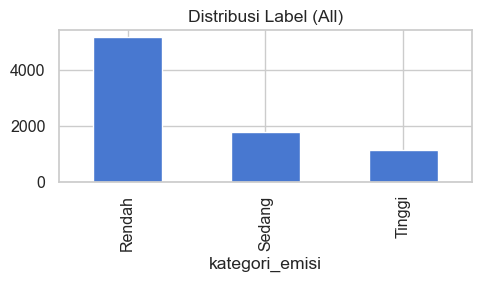

kategori_emisi,Rendah,Sedang,Tinggi
kecamatan,,,
Cilongok,222,24,7
Lumbir,158,19,14
Gumelar,143,24,8
Pekuncen,130,17,10
Ajibarang,124,22,10
Kedungbanteng,121,22,6
Wangon,115,21,14
Karanglewas,104,14,4
Rawalo,104,6,4


,road_km_per_km2,building_area_pct,green_area_pct,ratio_green_building,ratio_road_building
count,8072.000,8072.000,8072.000,8072.000,8072.000
mean,0.545,3.911,9.754,51870.703,30.483
std,0.704,5.288,9.730,93202.864,131.736
min,0.000,0.000,0.000,0.000,0.000
50%,0.325,1.229,6.741,2.570,0.009
90%,1.396,11.786,25.000,250000.000,0.153
95%,1.803,15.165,25.000,250000.000,232.188
99%,3.267,21.271,25.000,250000.000,697.734
max,6.496,25.000,28.485,250000.000,1535.585


In [65]:
# 1) Cek null/konstan
num_cols = ["road_km_per_km2","building_area_pct","green_area_pct",
            "ratio_green_building","ratio_road_building"]
print(feat[num_cols].isna().sum())           # NA check
print(feat[num_cols].nunique())              # fitur konstan?

# 2) Distribusi label keseluruhan
ax = (feat["kategori_emisi"]
      .value_counts()
      .reindex(["Rendah","Sedang","Tinggi"])
      .fillna(0)
      .plot(kind="bar", figsize=(5,3), title="Distribusi Label (All)"))
plt.tight_layout(); plt.show()

# 3) Distribusi label per-kecamatan (top 10 biar ringkas)
tmp = (feat.groupby(["kecamatan","kategori_emisi"])["grid_id"]
          .count().unstack(fill_value=0))
display(tmp.sort_values(tmp.columns.tolist(), ascending=False).head(10))

# 4) Ringkas statistik fitur (untuk mengonfirmasi p99 clipping efektif)
display(feat[num_cols].describe(percentiles=[.5,.9,.95,.99]).round(3))


6) SPLITTING → train/test per kecamatan (hold-out kecamatan)

In [66]:
def alias(df, targets):
    for name in targets:
        if name in df.columns:
            return name
    return None

# Petakan/rename agar konsisten
rename_pairs = {}

# 1) luas hijau → hijau_m2
src = alias(feat, ["hijau_m2", "luas_hijau_m2", "green_m2"])
if src is None:
    raise KeyError("Kolom luas hijau tidak ditemukan (cari: hijau_m2 / luas_hijau_m2 / green_m2).")
if src != "hijau_m2":
    rename_pairs[src] = "hijau_m2"

# 2) luas bangunan → bangunan_m2
src = alias(feat, ["bangunan_m2", "luas_bangunan_m2", "building_m2"])
if src is None:
    raise KeyError("Kolom luas bangunan tidak ditemukan (cari: bangunan_m2 / luas_bangunan_m2 / building_m2).")
if src != "bangunan_m2":
    rename_pairs[src] = "bangunan_m2"

# 3) panjang jalan → jalan_m
src = alias(feat, ["jalan_m", "panjang_jalan_m", "road_m"])
if src is None:
    raise KeyError("Kolom panjang jalan tidak ditemukan (cari: jalan_m / panjang_jalan_m / road_m).")
if src != "jalan_m":
    rename_pairs[src] = "jalan_m"

# Lakukan rename jika perlu
if rename_pairs:
    feat = feat.rename(columns=rename_pairs)

# 4) Rasio hijau/bangunan
if "ratio_green_building" not in feat.columns:
    # coba alias lain
    src_ratio_gb = alias(feat, ["rasio_hijau_bangunan"])
    if src_ratio_gb:
        feat = feat.rename(columns={src_ratio_gb: "ratio_green_building"})
    else:
        # hitung jika bahan ada
        if {"hijau_m2", "bangunan_m2"}.issubset(feat.columns):
            feat["ratio_green_building"] = feat["hijau_m2"] / (feat["bangunan_m2"] + 1.0)
        else:
            raise KeyError("Tidak bisa membuat ratio_green_building (butuh hijau_m2 & bangunan_m2).")

# 5) Rasio jalan/bangunan
if "ratio_road_building" not in feat.columns:
    src_ratio_rb = alias(feat, ["rasio_jalan_bangunan"])
    if src_ratio_rb:
        feat = feat.rename(columns={src_ratio_rb: "ratio_road_building"})
    else:
        if {"jalan_m", "bangunan_m2"}.issubset(feat.columns):
            feat["ratio_road_building"] = feat["jalan_m"] / (feat["bangunan_m2"] + 1.0)
        else:
            raise KeyError("Tidak bisa membuat ratio_road_building (butuh jalan_m & bangunan_m2).")

# Pastikan kolom target ada
if "kategori_emisi" not in feat.columns:
    # fallback umum: beberapa file pake 'emission_label' atau 'prediksi_kategori'
    if "emission_label" in feat.columns:
        feat = feat.rename(columns={"emission_label": "kategori_emisi"})
    elif "prediksi_kategori" in feat.columns:
        feat = feat.rename(columns={"prediksi_kategori": "kategori_emisi"})
    else:
        raise KeyError("Kolom target 'kategori_emisi' tidak ada. Jalankan labeling terlebih dahulu.")

df_train = feat[feat["kecamatan"].isin(TRAIN_KEC)].copy()
df_test  = feat[feat["kecamatan"].isin(TEST_KEC)].copy()
assert (len(df_train)>0) and (len(df_test)>0), "Split kosong. Cek ejaan kecamatan & isi data."

FEATURES = ["hijau_m2","bangunan_m2","jalan_m","ratio_green_building","ratio_road_building"]

# Validasi akhir kolom fitur
missing = [c for c in FEATURES if c not in df_train.columns]
if missing:
    raise KeyError(f"Kolom fitur hilang di TRAIN: {missing}")

X_train = df_train[FEATURES].astype(float).fillna(0.0).values
y_train = df_train["kategori_emisi"].astype(str).values

X_test  = df_test[FEATURES].astype(float).fillna(0.0).values
y_test  = df_test["kategori_emisi"].astype(str).values

print("Distribusi TRAIN:", pd.Series(y_train).value_counts().to_dict())
print("Distribusi TEST :", pd.Series(y_test).value_counts().to_dict())


Distribusi TRAIN: {'Rendah': 239, 'Sedang': 79, 'Tinggi': 47}
Distribusi TEST : {'Rendah': 87, 'Sedang': 76, 'Tinggi': 50}


CEK DATA BALANCE ATAU NGGA

In [73]:
def quick_summary(train_df, test_df, label_col="emission_category", feats=["road_density_km_per_km2","building_density_per_km2","green_percent"]):
    print("== Size ==")
    print("Train:", len(train_df), "Test:", len(test_df))
    print("\n== Label counts (train) ==")
    print(train_df[label_col].value_counts(), "\n")
    print("== Label counts (test) ==")
    print(test_df[label_col].value_counts(), "\n")
    
    print("== Label % (train) ==")
    print((train_df[label_col].value_counts(normalize=True)*100).round(2).astype(str) + "%\n")
    print("== Label % (test) ==")
    print((test_df[label_col].value_counts(normalize=True)*100).round(2).astype(str) + "%\n")
    
    print("== Feature summary (train) ==")
    print(train_df[feats].describe().T[['count','mean','std','min','50%','max']])
    print("\n== Feature summary (test) ==")
    print(test_df[feats].describe().T[['count','mean','std','min','50%','max']])
    
    print("\n== Samples per kecamatan (train) ==")
    print(train_df['kecamatan'].value_counts())
    print("\n== Samples per kecamatan (test) ==")
    print(test_df['kecamatan'].value_counts())

quick_summary(df_train, df_test, 
              label_col="kategori_emisi",
              feats=["road_km_per_km2","building_area_pct","green_area_pct"])


== Size ==
Train: 365 Test: 213

== Label counts (train) ==
kategori_emisi
Rendah    239
Sedang     79
Tinggi     47
Name: count, dtype: int64 

== Label counts (test) ==
kategori_emisi
Rendah    87
Sedang    76
Tinggi    50
Name: count, dtype: int64 

== Label % (train) ==
kategori_emisi
Rendah    65.48%\n
Sedang    21.64%\n
Tinggi    12.88%\n
Name: proportion, dtype: object
== Label % (test) ==
kategori_emisi
Rendah    40.85%\n
Sedang    35.68%\n
Tinggi    23.47%\n
Name: proportion, dtype: object
== Feature summary (train) ==
                   count       mean       std  min       50%        max
road_km_per_km2    365.0   0.526241  0.593895  0.0  0.409601   4.421022
building_area_pct  365.0   4.021089  5.198645  0.0  1.972487  25.000000
green_area_pct     365.0  10.026899  9.294601  0.0  8.617332  25.000000

== Feature summary (test) ==
                   count      mean       std  min       50%        max
road_km_per_km2    213.0  0.668019  0.611556  0.0  0.598012   3.553519
buildi

EDA Sesudah split 
→ untuk cek sanity bahwa train/test “fair” (nggak ada pergeseran distribusi besar atau kebocoran).

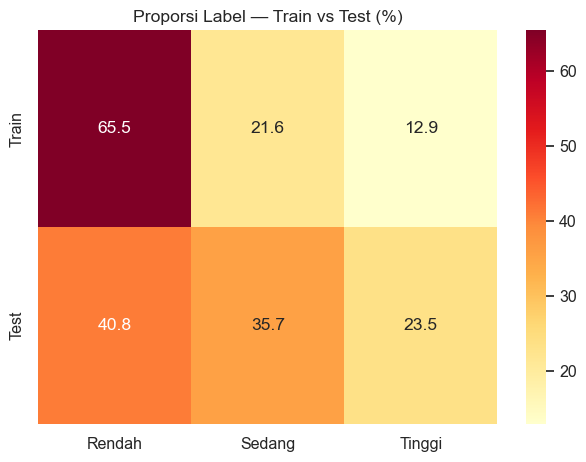

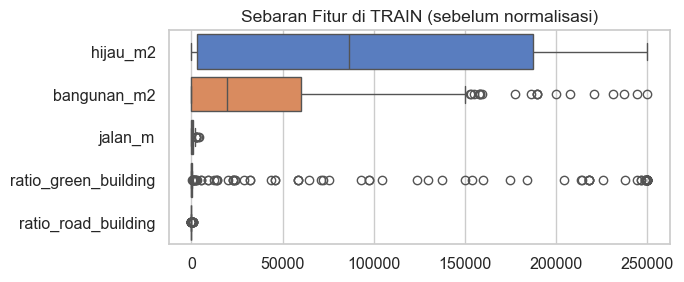

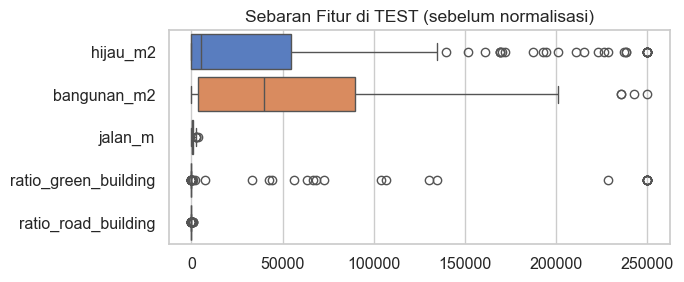

In [74]:
# 5) Bandingkan distribusi label train vs test
import seaborn as sns, pandas as pd, matplotlib.pyplot as plt

train_counts = pd.Series(y_train).value_counts().rename("Train")
test_counts  = pd.Series(y_test).value_counts().rename("Test")
distrib = pd.concat([train_counts, test_counts], axis=1).fillna(0)
distrib_pct = distrib.div(distrib.sum(axis=0), axis=1)*100
sns.heatmap(distrib_pct.T, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Proporsi Label — Train vs Test (%)"); plt.tight_layout(); plt.show()

# 6) Cek pergeseran fitur utama (boxplot sederhana)
plt.figure(figsize=(7,3))
sns.boxplot(data=pd.DataFrame(X_train, columns=FEATURES), orient="h")
plt.title("Sebaran Fitur di TRAIN (sebelum normalisasi)"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3))
sns.boxplot(data=pd.DataFrame(X_test, columns=FEATURES), orient="h")
plt.title("Sebaran Fitur di TEST (sebelum normalisasi)"); plt.tight_layout(); plt.show()


7) NORMALISASI → data siap model (fit scaler di TRAIN saja)
    (Balancing → setelah split, sebelum fit model)

In [75]:
# Oversampling HANYA di TRAIN
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Normalisasi fit di TRAIN_BAL lalu transform TEST
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_bal)
X_test_std  = scaler.transform(X_test)

# Label encoding untuk evaluasi/plot
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)  # ['Rendah','Sedang','Tinggi']

8) MODELING (SVM) → model terlatih

In [70]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}
svm = SVC(probability=True, class_weight=None, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(svm, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train_std, y_train_enc)

best_svm = gs.best_estimator_
print("[BEST PARAMS]:", gs.best_params_)
print("[CV F1_MACRO]:", round(gs.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[BEST PARAMS]: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
[CV F1_MACRO]: 0.9958


9) EVALUATION → F1, Confusion Matrix, Accuracy


Akurasi  : 0.9906
F1-Macro : 0.9890

=== Classification Report ===
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        87
      Sedang       1.00      0.97      0.99        76
      Tinggi       0.96      1.00      0.98        50

    accuracy                           0.99       213
   macro avg       0.99      0.99      0.99       213
weighted avg       0.99      0.99      0.99       213



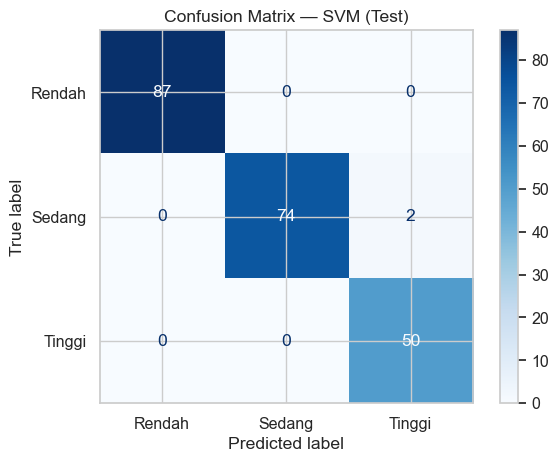

PermissionError: [Errno 13] Permission denied: 'E:\\KULIAH SEMESTER 7\\COMPUTING PROJECT\\CAPSTONEPROJECT\\outputs\\prediksi_grid_test_svm.csv'

In [71]:
y_pred_enc = best_svm.predict(X_test_std)
y_pred     = [classes[i] for i in y_pred_enc]

acc  = accuracy_score(y_test_enc, y_pred_enc)
f1m  = f1_score(y_test_enc, y_pred_enc, average="macro")
print(f"\nAkurasi  : {acc:.4f}")
print(f"F1-Macro : {f1m:.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_test_enc, y_pred_enc, target_names=classes))

# Confusion Matrix (biarkan seperti kode kamu)
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred_enc, display_labels=classes, cmap="Blues")
plt.title("Confusion Matrix — SVM (Test)")
plt.tight_layout(); plt.show()

# Simpan hasil prediksi per-grid test (ignore jika 'geometry' memang tidak ada)
pred_df = df_test.reset_index(drop=True).copy()
pred_df["prediksi_kategori"] = y_pred

OUT.mkdir(parents=True, exist_ok=True)  # pastikan folder ada
pred_df.drop(columns=["geometry"], errors="ignore") \
       .to_csv(OUT / "prediksi_grid_test_svm.csv", index=False, encoding="utf-8-sig")

print(f"✅ Tersimpan: {OUT/'prediksi_grid_test_svm.csv'}")
